# Look at image data

In [ ]:
import pandas as pd
from pathlib import Path
import cv2
import sys
sys.path.append("../src/")
from helper_functions.image_functions import show_image

In [34]:
dataset_info = "/home/mellanie/Desktop/Plating_2026-06-18.xlsx"

In [35]:
data = pd.read_excel(dataset_info)
print(data.shape)
data.head()

(28354, 13)


,Date,Nitrate concentration,Plate,Mode,Ecotype,Seed number for the specific concentration,Annotation,Annotator,Seed number on the plate,Image number\non the plate,stitched,reason for unusability of images,Comment
0,20240918,N4,1,L,Pu2-23,_001,yes,Roberto Zarazua,1.0,1,no_need,NaN,NaN
1,20240918,N4,1,L,Pu2-23,_002,yes,Roberto Zarazua,2.0,2,no_need,NaN,NaN
2,20240918,N4,1,L,Pu2-23,_003,yes,Roberto Zarazua,3.0,3,no_need,NaN,NaN
3,20240918,N4,1,L,Pu2-23,x,yes,Roberto Zarazua,4.0,4,no_need,5. tangled root hairs/overlap with other root ...,NaN
4,20240918,N4,1,L,Pu2-23,_004,yes,Roberto Zarazua,5.0,5,no_need,NaN,NaN


In [36]:
annotated_images = data[data["Annotation"] == "yes"]
annotated_images.shape

(551, 13)

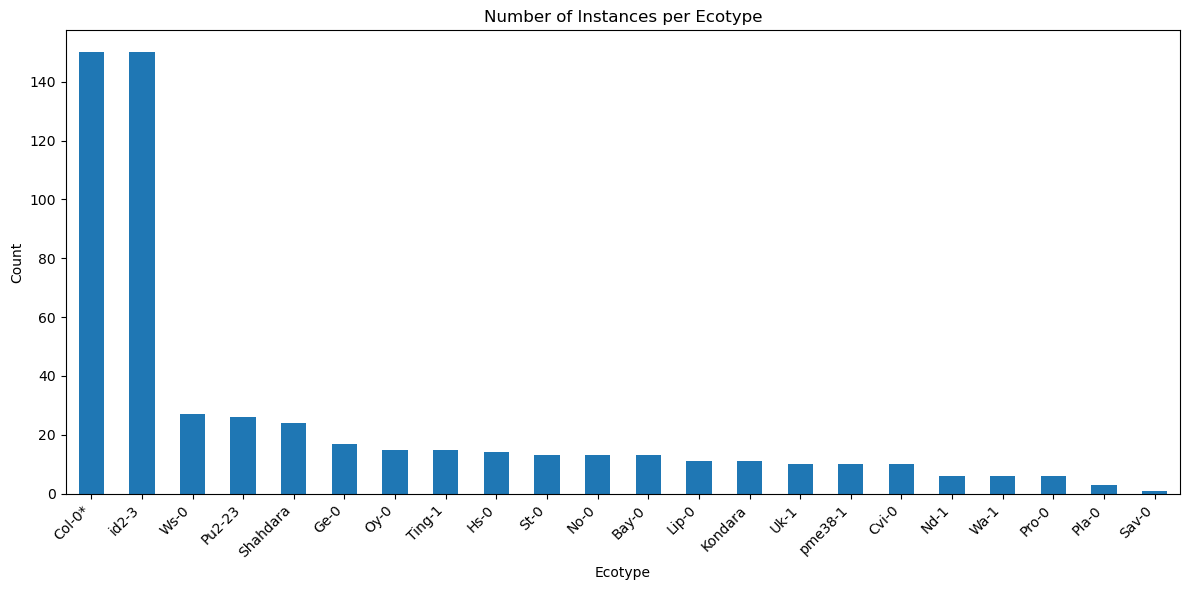

In [45]:
import matplotlib.pyplot as plt

counts = annotated_images["Ecotype"].value_counts()

plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.xlabel("Ecotype")
plt.ylabel("Count")
plt.title("Number of Instances per Ecotype")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Let's say I wanted all Uk-1 plants

In [44]:
genotype = "Uk-1"
filtered = annotated_images[annotated_images["Ecotype"] == genotype]

images = []
jsons = []

path_stub = "/home/mellanie/Desktop/Annotated_dataset/"
for index, seed_log in filtered.iterrows():
    date = seed_log["Date"]
    nitrogen = seed_log["Nitrate concentration"]
    plate = seed_log["Plate"]
    number = int(seed_log["Seed number on the plate "])
    
    name = path_stub + f"{date}_{nitrogen}_Plate{plate}_DAG6_1000_L/{number:06d}.tif"
    label= path_stub + f"{date}_{nitrogen}_Plate{plate}_DAG6_1000_L/labelme_annotations/{number:06d}.json"

    images.append(name)
    jsons.append(label)


    print("\"" + label + "\",")

"/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/labelme_annotations/000007.json",
"/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/labelme_annotations/000008.json",
"/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/labelme_annotations/000009.json",
"/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/labelme_annotations/000010.json",
"/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/labelme_annotations/000011.json",
"/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/labelme_annotations/000012.json",
"/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate6_DAG6_1000_L/labelme_annotations/000013.json",
"/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate6_DAG6_1000_L/labelme_annotations/000014.json",
"/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate6_DAG6_1000_L/labelme_annotations/000015.json",
"/home/mellanie/Desktop/Annotated_dat

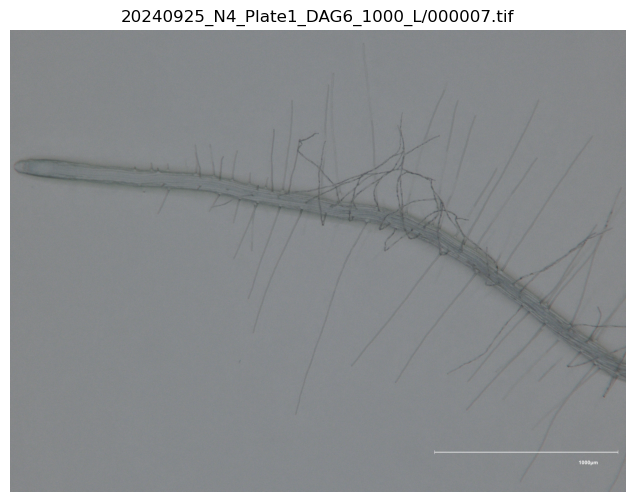

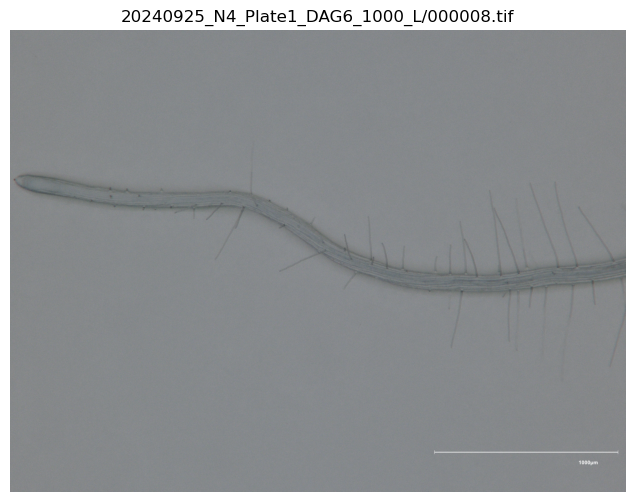

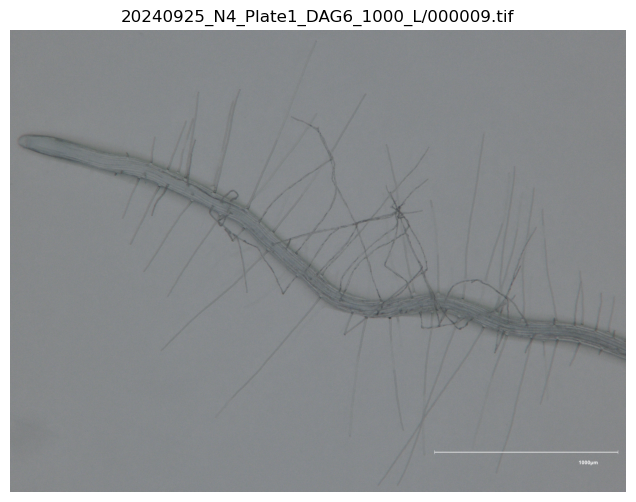

In [ ]:
path_stub = "/home/mellanie/Desktop/Annotated_dataset/"

for index, image in enumerate(images):
    img_path = path_stub + image

    img = cv2.imread(img_path)
    show_image(img, title=image)

    if index == 2:
        break